Автор: Алёна Опольская

Дата: 1.04.2026

# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
#Импортируем библиотеку pandas
import pandas as pd
#Считываем файл и сохраняем в датафрейм
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')
#Выводим первые 5 строк датафрейма
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [2]:
#Рассчитаем кол-во уникальных сессий для каждого пользователя
sessions_per_user = sessions_history.groupby('user_id')['session_id'].nunique()
#Выведем данные в порядке убывания (чтобы посмотреть максимальное число)
sessions_per_user.sort_values(ascending=False).head()

user_id
10E0DEFC1ABDBBE0    10
6A73CB5566BB494D    10
8A60431A825D035B     9
D11541BAC141FB94     9
5BCFE7C4DCC148E9     9
Name: session_id, dtype: int64

In [3]:
#Выделим пользователя с наибольшим количеством сессий
max_user = sessions_per_user.idxmax()
#Выведем данные из таблицы для этого пользователя
max_user_data = sessions_history[sessions_history['user_id']==max_user]
max_user_data

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

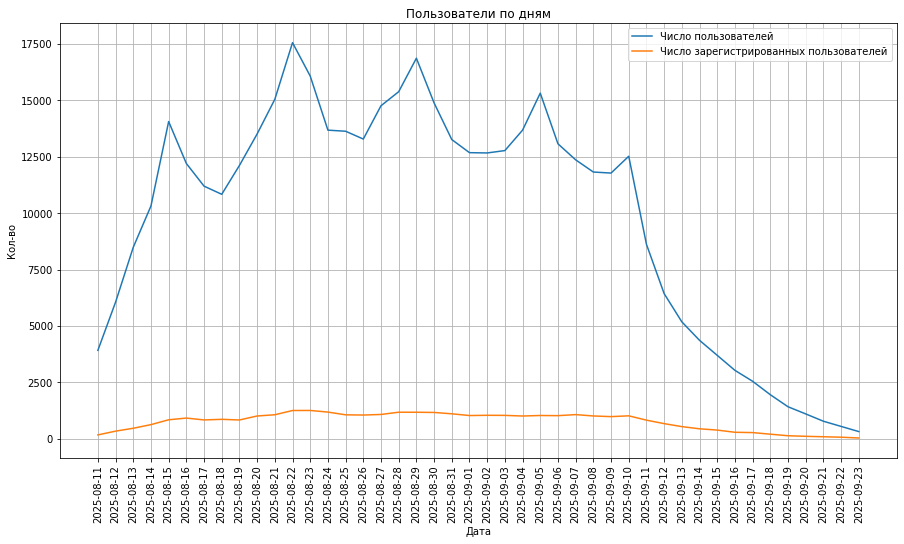

In [4]:
#Посчитаем число уникальных пользователей по дням
day_users = sessions_history.groupby('session_date')['user_id'].nunique()
#Посчитаем число зарегистрированных пользователей по дням
day_registrations = sessions_history[sessions_history['registration_flag']==1].groupby('session_date')['user_id'].nunique()
#Строим график
import matplotlib.pyplot as plt
plt.figure(figsize=(15,8))
plt.plot(day_users, label='Число пользователей')
plt.plot(day_registrations, label='Число зарегистрированных пользователей')
plt.title('Пользователи по дням')
plt.xlabel('Дата')
plt.ylabel('Кол-во')
plt.grid()
plt.legend()
plt.xticks(rotation=90)
plt.show()

В начале рассматриваемого периода виден рост числа пользователей, далее колебания от 12500 до 17500 пользователей в день. С 10 сентября и до конца периода замечен спад кол-ва пользователей. Число зарегистрированных пользователей менялось более плавно - сначала можно заметить рост, затем достаточно стабильный показатель изо дня в день (без сильных колебаний), а к концу периода, так же, спад.

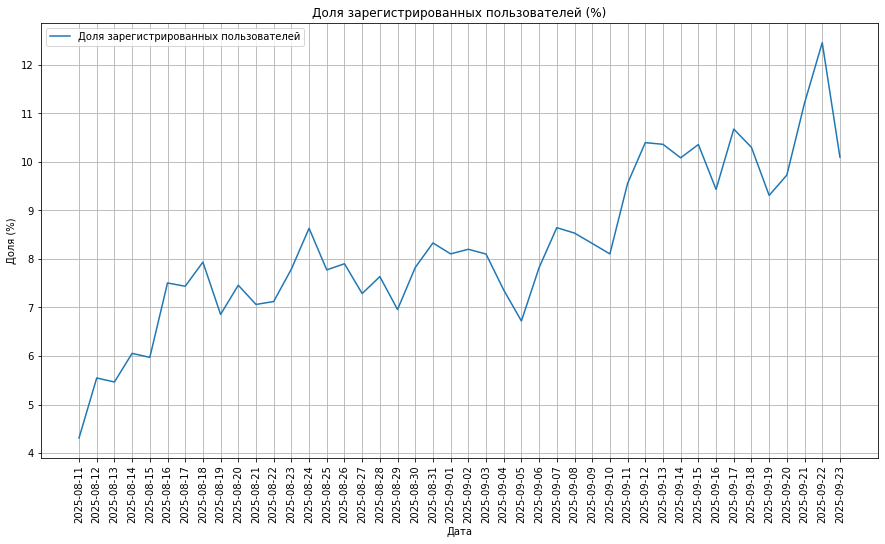

In [5]:
#Посчитаем долю зарегистрированных пользователей от числа пользователей по дням
day_share = day_registrations/day_users*100
#Строим график
plt.figure(figsize=(15,8))
plt.plot(day_share, label='Доля зарегистрированных пользователей')
plt.title('Доля зарегистрированных пользователей (%)')
plt.xlabel('Дата')
plt.ylabel('Доля (%)')
plt.grid()
plt.legend()
plt.xticks(rotation=90)
plt.show()

Несмотря на колебания, заметен рост доли зарегистрированных пользователей в рассматриваемом периоде. В начале периода это было около 4.5%, а к концу периода - около 10%. Пик был достигнут 22 сентября (около 12.5%). 

Стоит отметить, что доля зарегистрированных пользователей росла несмотря на сильное снижение общего кол-ва пользователей в конце периода. Возможно в этот период была запущена рекламная кампания (стоит уточнить), которая привлекала пользователей в приложение (с чем связан рост их кол-ва), а к концу периода в приложении остались только заинтересованные пользователи (общее кол-во пользователей снизилось, а доля зарегистрированных нет). 

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

In [6]:
#Выделим первые сессии
first_sessions = sessions_history[sessions_history['session_number']==1]
#Посчитаем кол-во первых сессий для каждого кол-ва просмотренных страниц
page_counter_sessions = first_sessions.groupby('page_counter')['session_id'].count()
page_counter_sessions

page_counter
1     8978
2    32494
3    50939
4    32739
5     8075
6      777
7       37
Name: session_id, dtype: int64

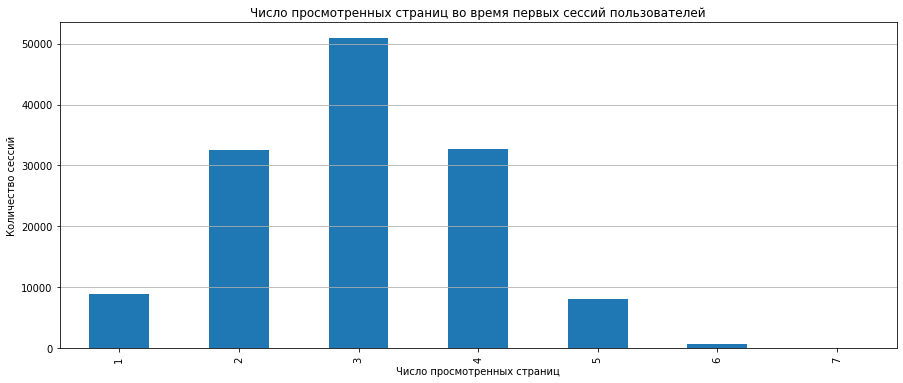

In [7]:
#Строим столбчатую диаграмму
page_counter_sessions.plot(kind='bar',figsize=(15,6))
plt.title('Число просмотренных страниц во время первых сессий пользователей')
plt.xlabel('Число просмотренных страниц')
plt.ylabel('Количество сессий')
plt.grid(axis='y')
plt.show()

Во время первой сессии чаще пользователи просматривают более 1 страницы. Пик кол-ва сессий приходится на 3 страницы (около 51 тыс. сессий), чуть реже (примерно по 32.5 тыс. сессий) пользователи смотрят 2 и 4 страницы. На кол-ве 5 страниц кол-во первых сессий резко падает, и далее снижается.

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

In [8]:
#Создаем дополнительный столбец
sessions_history['good_session'] = (sessions_history['page_counter']>=4).astype(int)
#Проверяем датасет на наличие нового столбца 
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,good_session
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone,0
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android,1
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC,1
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android,1
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android,0


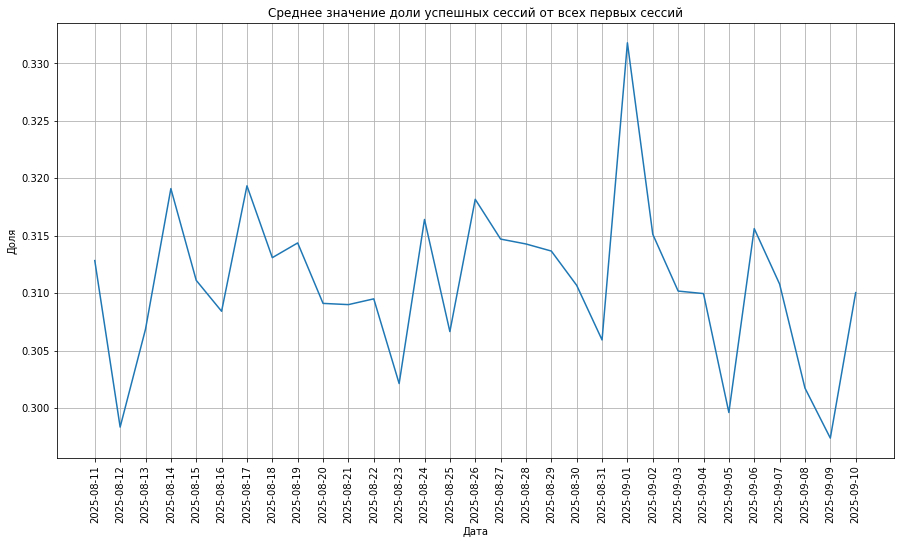

In [9]:
#Считаем долю успешных сессий от всех первых сессий по дням
first_sessions = sessions_history[sessions_history['session_number']==1]
good_share = first_sessions.groupby('session_date')['good_session'].mean()
#Строим график
plt.figure(figsize=(15,8))
plt.plot(good_share)
plt.title('Среднее значение доли успешных сессий от всех первых сессий')
plt.xlabel('Дата')
plt.ylabel('Доля')
plt.grid()
plt.xticks(rotation=90)
plt.show()

Несмотря на колебания в графике, стоит обратить внимание на цифры - доля успешных сессий (4+ страниц) по дням достаточно стабильна, сохраняется в диапозоне 30-33%. Также нужно отметить, что график ограничен датой 10 сентября - мы рассматриваем только первые сессии, а значит, в остальные дни их не было. Здесь так же стоит вспомнить, что как раз с 10 сентября было замечено снижение общего числа пользователей (график в пункте 1.3). 

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [10]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = p*0.03  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [11]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = day_users.mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size/(avg_daily_users/2))

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {round(avg_daily_users)} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [12]:
#Считываем файл и сохраняем в датафрейм
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')
#Посмотрим даты в датасете
sessions_test_part['session_date'].unique()

array(['2025-10-14'], dtype=object)

In [13]:
#В датасете данные за 1 день - значит можем далее работать просто с датасетом, не выбирая 1 день
#Считаем количество уникальных пользователей в каждой из экспериментальных груп
users_in_group = sessions_test_part.groupby('test_group')['user_id'].nunique()
#Считаем процентную разницу в кол-ве пользователей в группах
users_in_a = users_in_group['A']
users_in_b = users_in_group['B']
r = 100*((users_in_a-users_in_b)/users_in_a)
print(round(r,2))

0.74


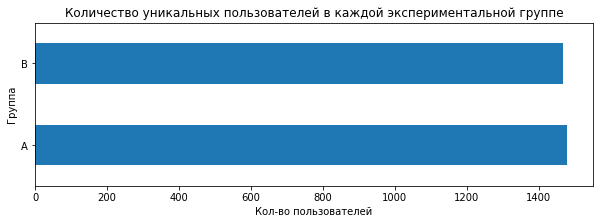

In [14]:
#Строим график
users_in_group.plot(kind='barh', figsize=(10,3))
plt.title('Количество уникальных пользователей в каждой экспериментальной группе')
plt.xlabel('Кол-во пользователей')
plt.ylabel('Группа')
plt.show()

Процентная разница в кол-ве уникальных пользователей в группах менее 1% (0,74%), что позволяет подтвердить корректное распределение пользователей без перекосов.

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [15]:
#Выделим уникальных пользователей в каждой группе
users_a = sessions_test_part[sessions_test_part['test_group']=='A']['user_id'].unique()
users_b = sessions_test_part[sessions_test_part['test_group']=='B']['user_id'].unique()
#Посчитаем кол-во пользователей, которые попали в обе группы
users_a_b = list(set(users_a)&set(users_b))
users_a_b

[]

Пользователей, которые встречаются одновременно в группах А и В нет. 

#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


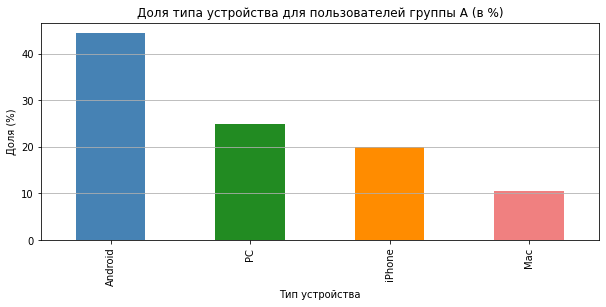

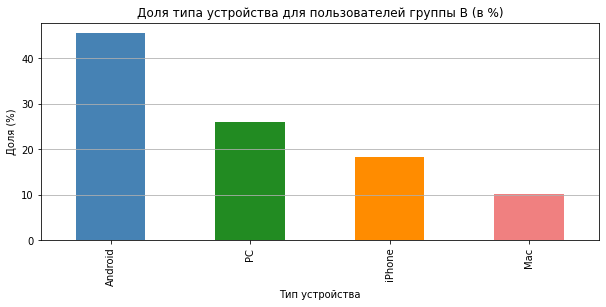

In [16]:
#Разделим данные на группы A и B
group_a = sessions_test_part[sessions_test_part['test_group']=='A']
group_b = sessions_test_part[sessions_test_part['test_group']=='B']
#Группируем по устройствам внутри каждой группы и считаем долю (в%)
users_per_device_a = group_a.groupby('device')['user_id'].nunique()
device_share_a = round(users_per_device_a/users_per_device_a.sum()*100,2)
users_per_device_b = group_b.groupby('device')['user_id'].nunique()
device_share_b = round(users_per_device_b/users_per_device_b.sum()*100,2)
#Зададим одинаковый порядок (так будет удобнее сравнивать графики)
order = device_share_a.sort_values(ascending=False).index
color_map = {'Android': '#4682B4', 'PC': '#228B22', 'iPhone': '#FF8C00', 'Mac': '#F08080'}
colors = [color_map[x] for x in order]
#Строим диаграммы
device_share_a.loc[order].plot(kind='bar',figsize=(10,4), color=colors)
plt.title('Доля типа устройства для пользователей группы A (в %)')
plt.xlabel('Тип устройства')
plt.ylabel('Доля (%)')
plt.grid(axis='y')
plt.show()

device_share_b.loc[order].plot(kind='bar',figsize=(10,4), color=colors)
plt.title('Доля типа устройства для пользователей группы B (в %)')
plt.xlabel('Тип устройства')
plt.ylabel('Доля (%)')
plt.grid(axis='y')
plt.show()

Распределение по устройствам в группах А и В очень схоже. Около 45% в каждой группе - Android, около 25% - PC, около 20% - iPhone и 10% - Mac. 

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.

Пользователи распределены по регионам в группах А и В практически одинаково. 

#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

В ходе мониторинга A/B теста было выявлено несущественное разичие в кол-ве пользователей каждой группы (менее 1%). Пересечение пользователей из тестовой и контрольной группы не обнаружено, а значит выборки являются независимыми. Внутри каждой группы пользователи равномерно распределены по типу устройства и региону. Все это позволяет сделать вывод о том, что A/B тест проходит корректно без каких-либо нарушений. 

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [18]:
#Считываем файл и сохраняем в датафрейм
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')
#Создаем дополнительный столбец
sessions_test['good_session'] = (sessions_test['page_counter']>=4).astype(int)
#Проверяем датасет на наличие нового столбца 
sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.

В качестве основной метрики выберем долю успешных сессий (где пользователь просматривал 4 и более страниц). Это как раз является показателем удовлетворенности контентом и системой рекомендаций.
В качестве прокси-метрики можно было бы смотреть на среднее кол-во просматриваемых страниц и долю зарегистрированных пользователей (ведь чем интереснее контент для пользователя, тем выше его готовность пройти регистрацию и даже оформиит платную подписку). 
Барьерными метриками могут стать общее кол-во пользователей, а также их распределение по устройствам (чтобы исключить технические ошибки для какого-то типа устройств).

H0(нулевая гипотеза): доли успешных первых сессий в группах А и В не различаются.
H1 (альтернативная гипотеза): доля успешных первых сессий в группе B выше, чем в группе А.

#### 4.3. Сравнение доли успешных сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [19]:
first_sessions = sessions_test[sessions_test['session_number']==1]
#Считаем долю успешных сессий по группам
good_share = first_sessions.groupby('test_group')['good_session'].mean()
good_share_a = round(good_share['A'],3)
good_share_b = round(good_share['B'],3)
#Считаем разницу между долями
diff = round(good_share_b-good_share_a,3)
print(f'Доля успешных сессий: в группе A = {good_share_a}, в группе B = {good_share_b}')
print(f'Разница между долями (B-A) = {diff}')

Доля успешных сессий: в группе A = 0.316, в группе B = 0.315
Разница между долями (B-A) = -0.001


<span style="color:blue">Привет! У меня здесь возник вопрос - почему в пункте 4.3 говорится о первых сессиях, а в пункте 4.4 о всех сессиях? Я сейчас сделала так, чтобы было логично с пунктом 4.4, но если в коде 4.3 брать только первые сессии, то в тестовой выборке не будет на 1.1% выше, наоборот получится ниже.<b></b></span>

#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [20]:
from statsmodels.stats.proportion import proportions_ztest
#Считаем размеры групп
n_a=first_sessions[first_sessions['test_group']=='A'].shape[0]
n_b=first_sessions[first_sessions['test_group']=='B'].shape[0]
#Считаем количество успехов
m_a=first_sessions[(first_sessions['test_group']=='A')&(first_sessions['good_session']==1)].shape[0]
m_b=first_sessions[(first_sessions['test_group']=='B')&(first_sessions['good_session']==1)].shape[0]
#Считаем доли
p_a=m_a/n_a
p_b=m_b/n_b
# Проверяем предпосылку о достаточном количестве данных
if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10): 
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')
#Устанавливаем уровень значимости
alpha = 0.05
#Z-test
stat, p_value = proportions_ztest(
[m_b, m_a],
[n_b, n_a], alternative='larger')
print(f'p-value = {p_value}')  

if p_value > alpha:
    print('Нулевая гипотеза находит подтверждение!')
else:
    print('Нулевая гипотеза не находит подтверждения!')

Предпосылка о достаточном количестве данных выполняется!
p-value = 0.5783523649187868
Нулевая гипотеза находит подтверждение!


#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

В рамках A/B теста мы рассмотрели как новый алгоритм рекомендаций влияет на поведение пользователей развлекательного приложения.

В контрольную группу A вошли пользователи, которые использовали старый алгоритм рекомендаций, а в тестовую группу B - пользователи, которые использовали новый алгоритм. Размер групп не имел существенных различий. Выборки были независимы, и внутри каждой группы пользователи равномерно распределены по типу устройства и региону.

Ключевой метрикой стала доля успешных первых сессий (когда пользователь просмотрел 4 или больше страниц). В тестовой группе замечено небольшое снижение ключевой метрики (доля успешных сессий в группе A = 31.6%, в группе B = 31.5%).

Используя односторонний Z-тест пропорций, мы рассмотрели, является ли данное изменение доли значимым. Уровень значимости = 0.05, а p-value = 0.578, что превышает уровень значимости. Это позволяет заявить, что  статистически значимых доказательств позитивного влияния нового алгоритма на ключевую метрику не обнаружено, и оснований отвергнуть нулевую гипотезу нет. На основании этого нельзя сделать вывод, что внедрение нового алгоритма рекомендаций окажет ожидаемое позитивное влияние на поведение пользователей приложения. 